<a href="https://colab.research.google.com/github/seelasairani7730-wq/Machine-Learning-Portfolio/blob/main/03_K-Nearest%20Neighbors/KNN_Wine_Classification/KNN_Wine_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Classification using K-Nearest Neighbors

## Project Overview

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that can be used for classification and regression problems.

In this project, KNN is used to classify wine samples into different wine classes based on their chemical properties.

The project demonstrates the complete machine learning workflow, including data exploration, feature scaling, model training, selecting an appropriate value of K, prediction, and model evaluation.

## Problem Statement

The objective of this project is to build a machine learning model that classifies a wine sample into one of three wine classes based on its chemical characteristics.

## Machine Learning Algorithm

**K-Nearest Neighbors (KNN)**

KNN classifies a new data point by finding the K training samples that are closest to it and assigning the class that appears most frequently among those neighbors.

Because KNN relies on distances between data points, feature scaling is an important preprocessing step.

## Dataset

The project uses the Wine dataset provided by Scikit-learn.

The dataset contains chemical measurements of wine samples belonging to three different classes.

## Project Workflow

1. Import required libraries
2. Load the Wine dataset
3. Understand the dataset
4. Perform Exploratory Data Analysis
5. Analyze the target classes
6. Split the dataset into training and testing sets
7. Scale the features
8. Select an appropriate value of K
9. Train the KNN model
10. Make predictions
11. Evaluate model performance
12. Analyze the confusion matrix
13. Save the trained model


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The Wine dataset is available directly through Scikit-learn.

It contains chemical measurements of wine samples along with the class of each wine sample.


In [2]:
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = pd.Series(
    wine.target,
    name="target"
)

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (178, 13)
Target shape: (178,)


In [3]:
# Create a DataFrame

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Dataset Exploration

The Wine dataset contains 13 numerical features representing different chemical properties of wine samples.

We first inspect the feature values and target classes to understand the structure of the dataset.


In [4]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
print("Feature names:")
print(list(X.columns))

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [7]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [8]:
print("Target Class Distribution:")
print(y.value_counts().sort_index())

Target Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


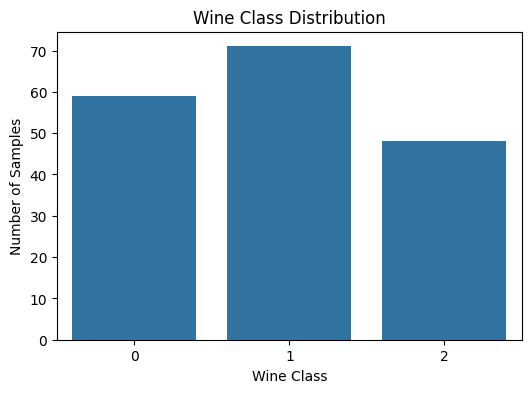

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")

plt.show()

In [10]:
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Feature Distributions

The Wine dataset contains 13 numerical features with different ranges and distributions.

Visualizing the distributions helps us understand the characteristics of the input variables before applying feature scaling.


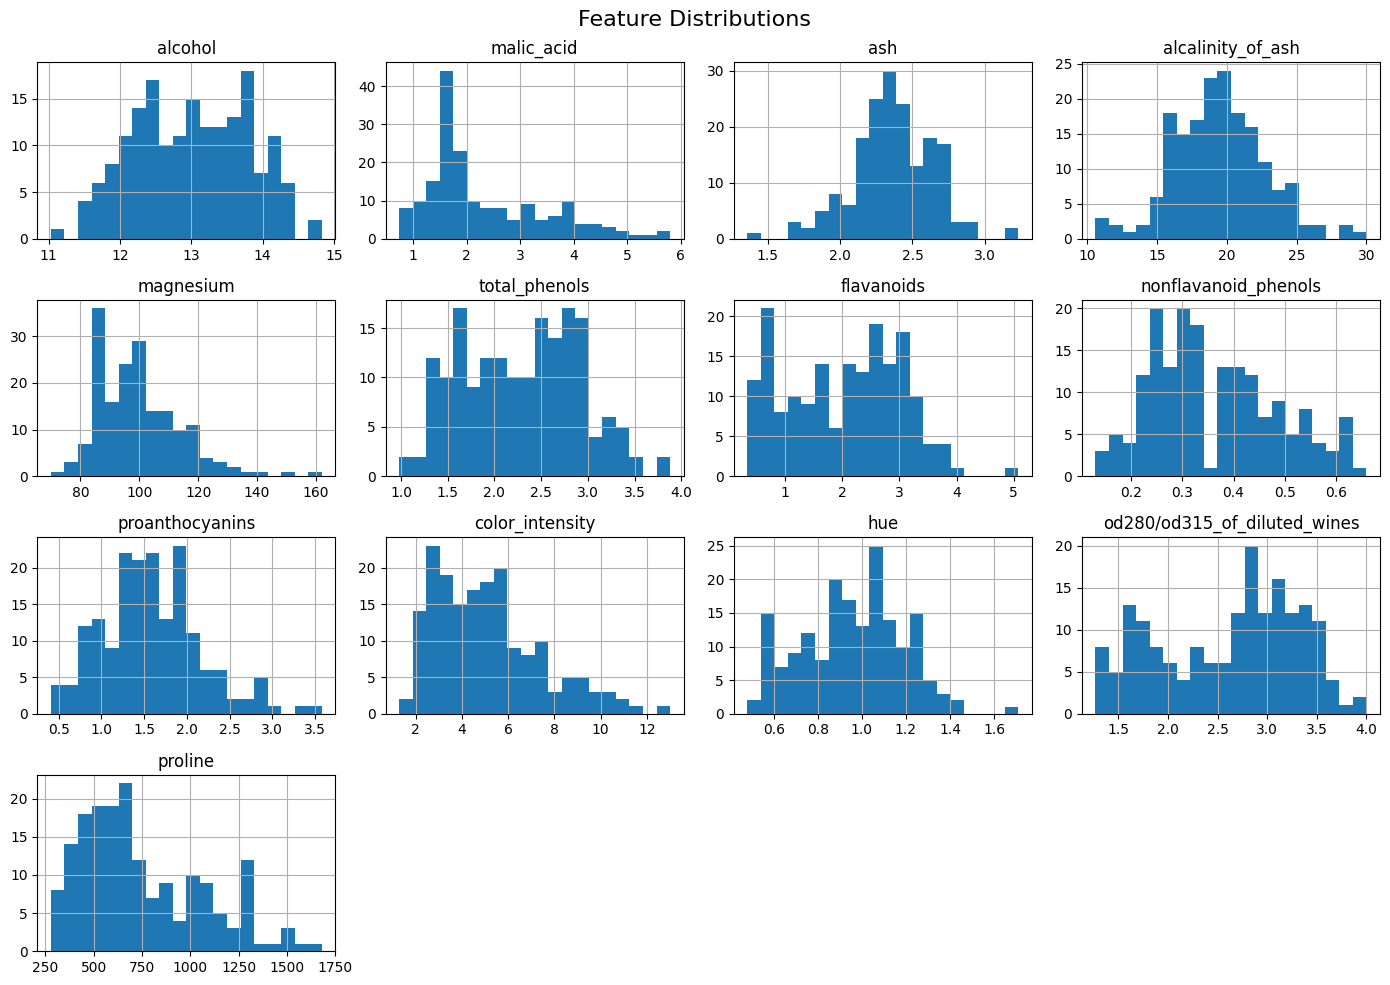

In [12]:
X.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

## Train-Test Split

The dataset is divided into training and testing sets before feature scaling.

* **80%** of the data is used for training.
* **20%** is reserved for testing.
* `random_state=42` ensures reproducibility.
* Stratification maintains a similar proportion of the three wine classes in both sets.

The split is performed before scaling to prevent data leakage from the test set.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)


## Feature Scaling

KNN is a distance-based algorithm. It calculates the distance between data points to identify their nearest neighbors.

Since the features in the Wine dataset have different numerical ranges, features with larger values could dominate the distance calculation.

To prevent this, **StandardScaler** is used to standardize the features.

The scaler is fitted only on the training data and then applied to both the training and testing data. This prevents data leakage.


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (142, 13)
Scaled X_test shape: (36, 13)


In [15]:
print("Training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))

Training feature means:
[ 1.09781120e-15 -2.57227729e-16  9.52485352e-16  5.50127236e-16
  1.95461800e-17 -2.89283464e-16  2.00152883e-16 -9.71054223e-16
 -1.57933134e-16  4.45066519e-16 -9.34307405e-16  1.03047461e-15
 -2.07971355e-16]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Selecting the Optimal Value of K

The value of **K** controls how many neighboring samples are considered when making a prediction.

* A very small K can make the model sensitive to noise.
* A very large K can make the model too generalized.

Therefore, multiple values of K are tested and their performance is compared to identify a suitable value for this dataset.


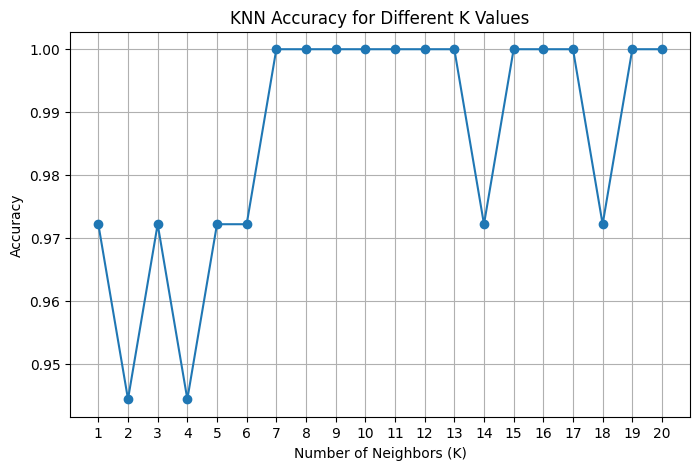

In [16]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [17]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 7
Best Accuracy: 1.0


In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": range(1, 21)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best K:", grid_search.best_params_["knn__n_neighbors"])
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best K: 13
Best Cross-Validation Accuracy: 0.9650246305418719


In [20]:
best_knn_model = grid_search.best_estimator_

print("Final KNN model selected successfully!")
print("Best K:", grid_search.best_params_["knn__n_neighbors"])

Final KNN model selected successfully!
Best K: 13


In [21]:
y_pred = best_knn_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predictions:
[0 2 0 1 1 0 0 1 1 2]

First 10 actual values:
[0 2 0 1 1 0 0 1 1 2]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 1.0
Test Accuracy (%): 100.0


## Confusion Matrix

The confusion matrix shows how the KNN model classified samples from each wine class.

It helps identify whether any samples from one wine class were incorrectly classified as another class.


In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


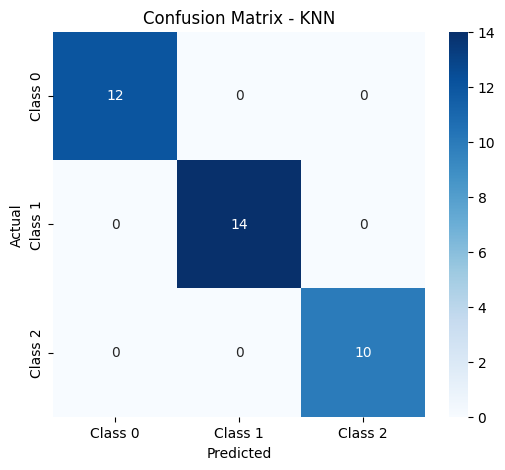

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1", "Class 2"],
    yticklabels=["Class 0", "Class 1", "Class 2"]
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Class 0", "Class 1", "Class 2"]
))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



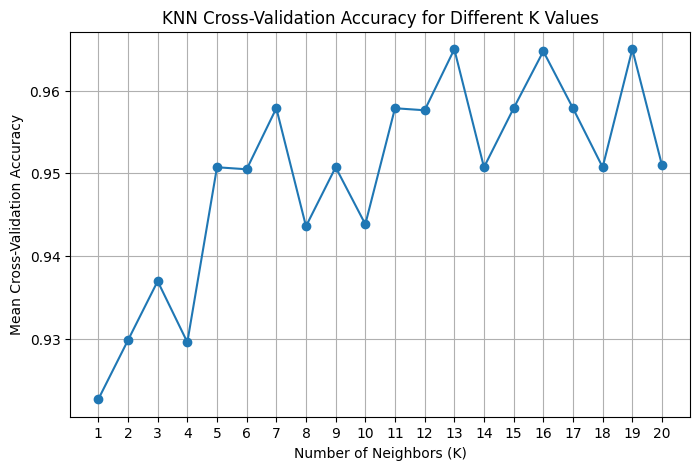

In [26]:
cv_results = pd.DataFrame(grid_search.cv_results_)

k_performance = cv_results[
    ["param_knn__n_neighbors", "mean_test_score"]
].copy()

k_performance["K"] = k_performance["param_knn__n_neighbors"].astype(int)

k_performance = k_performance.sort_values("K")

plt.figure(figsize=(8, 5))

plt.plot(
    k_performance["K"],
    k_performance["mean_test_score"],
    marker="o"
)

plt.title("KNN Cross-Validation Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

## Saving the Model

The selected StandardScaler and KNN classifier are stored together in a single Scikit-learn pipeline.

The pipeline is saved so that the trained model can be reused later without manually repeating the feature scaling process.


In [27]:
import joblib

joblib.dump(
    best_knn_model,
    "knn_wine_classification.pkl"
)

print("KNN pipeline saved successfully!")

KNN pipeline saved successfully!


In [28]:
import os

print(
    "Model exists:",
    os.path.exists("knn_wine_classification.pkl")
)

Model exists: True


In [29]:
loaded_knn = joblib.load("knn_wine_classification.pkl")

loaded_pred = loaded_knn.predict(X_test)

print("Predictions match:", np.array_equal(y_pred, loaded_pred))

Predictions match: True
